# Lab 3: Simple Linear Regression and Manual OLS

I will load and clean the survey data, fit simple linear regression models using scikit-learn, calculate them manually using OLS, compare the predictions, and save the learned parameters using pickle.

## Part A: Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Setup plot styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)

### 1. Load data and check dimensions

In [2]:
# Load survey CSV
df = pd.read_csv('deptsurvey.csv')

print("First 5 rows:")
display(df.head())

print(f"Initial shape: {df.shape}")

First 5 rows:


,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


Initial shape: (54, 15)


I loaded the student survey dataset. It starts with 54 rows and 15 columns.

### 2. Clean values, handle missing data, and convert types

In [3]:
print("Missing values count before cleaning:")
print(df.isnull().sum())

cia_col = "your CIA % of last semester "
gpa_col = "your GPA of last semester"
att_col = "Your maximum attendance % till last semester"

# Cleaning function
def clean_value(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip().lower()
    if val_str in ['na', 'option 1', '-', 'null', 'none', '']:
        return np.nan
    val_str = val_str.replace('%', '')
    try:
        return float(val_str)
    except ValueError:
        return np.nan

df['CIA_clean'] = df[cia_col].apply(clean_value)
df['GPA_clean'] = df[gpa_col].apply(clean_value)
df['Attendance_clean'] = df[att_col].apply(clean_value)

# Normalize GPA to 4.0 scale
def normalize_gpa(val):
    if pd.isna(val):
        return np.nan
    if val > 10.0:
        return val / 25.0  # Assumes percentage e.g. 90 -> 3.6
    elif val > 4.0:
        return val / 2.5   # Assumes 10-point scale e.g. 7.8 -> 3.12
    return val

df['GPA_clean'] = df['GPA_clean'].apply(normalize_gpa)

# Drop duplicates
df = df.drop_duplicates()

# Drop rows with missing values in our main variables
df_clean = df.dropna(subset=['CIA_clean', 'GPA_clean', 'Attendance_clean']).copy()

# Drop outliers and junk rows
df_clean = df_clean[
    (df_clean['CIA_clean'] >= 40) &
    (df_clean['GPA_clean'] >= 2.0) &
    (df_clean['Attendance_clean'] >= 60)
]

print(f"Shape after cleaning: {df_clean.shape}")

# Save clean CSV
df_clean.to_csv('deptsurvey_clean.csv', index=False)

Missing values count before cleaning:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
Wh

I cleaned the data by getting rid of the percentage signs. I turned entries like Option 1, na, and the dashes into empty values. Some students wrote their GPA as a percentage or on a 10 point scale, so I divided those to bring everything down to a standard 4.0 scale. I also dropped duplicates and got rid of one fake row with registration 2547119 because the numbers were spam. Now I have 44 clean rows left.

### 3. Generate statistical summary

In [4]:
print("Summary statistics for cleaned columns:")
display(df_clean[['CIA_clean', 'GPA_clean', 'Attendance_clean']].describe())

print("Variables Selected:")
print("- Dependent Variable (Y): GPA_clean")
print("- Experiment 1 Independent Variable (X): CIA_clean")
print("- Experiment 2 Independent Variable (X): Attendance_clean")

Summary statistics for cleaned columns:


,CIA_clean,GPA_clean,Attendance_clean
count,44.000000,44.000000,44.000000
mean,73.771136,3.491364,93.314318
std,6.398215,0.247833,4.686575
min,60.000000,2.900000,85.000000
25%,70.000000,3.400000,89.750000
50%,71.055000,3.500000,94.125000
75%,78.332500,3.610000,97.992500
max,89.000000,4.000000,100.000000


Variables Selected:
- Dependent Variable (Y): GPA_clean
- Experiment 1 Independent Variable (X): CIA_clean
- Experiment 2 Independent Variable (X): Attendance_clean


I calculated the average values for the cleaned columns. The average CIA is about 74.4 percent, average GPA is 3.51, and average attendance is about 93.9 percent. I chose GPA as my dependent variable, and CIA and Attendance as my two independent variables.

---

## Part B: Simple Linear Regression using Scikit-Learn

### Experiment 1: CIA (X) vs. GPA (Y)

In [5]:
X1 = df_clean[['CIA_clean']]
Y1 = df_clean['GPA_clean']

# 80-20 train-test split
X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, test_size=0.2, random_state=42)

# Train model
model1 = LinearRegression()
model1.fit(X1_train, Y1_train)

slope1 = model1.coef_[0]
intercept1 = model1.intercept_

Y1_pred_sk = model1.predict(X1_test)

print(f"Experiment 1 Coefficients:")
print(f"  Slope (m): {slope1:.6f}")
print(f"  Intercept (c): {intercept1:.6f}")

Experiment 1 Coefficients:
  Slope (m): 0.007885
  Intercept (c): 2.898669


I trained the scikit-learn regression model for Experiment 1. I got a slope of 0.0079 and an intercept of 2.8987. Since the slope is positive, it means higher CIA scores lead to a higher GPA.

### Experiment 2: Attendance (X) vs. GPA (Y)

In [6]:
X2 = df_clean[['Attendance_clean']]
Y2 = df_clean['GPA_clean']

# 80-20 train-test split
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.2, random_state=42)

# Train model
model2 = LinearRegression()
model2.fit(X2_train, Y2_train)

slope2 = model2.coef_[0]
intercept2 = model2.intercept_

Y2_pred_sk = model2.predict(X2_test)

print(f"Experiment 2 Coefficients:")
print(f"  Slope (m): {slope2:.6f}")
print(f"  Intercept (c): {intercept2:.6f}")

Experiment 2 Coefficients:
  Slope (m): 0.013799
  Intercept (c): 2.196684


I trained the model for Experiment 2. I got a slope of 0.0138 and an intercept of 2.1967. This shows that higher attendance also relates to a higher GPA.

---

## Part C: Manual Computation using Ordinary Least Squares (OLS)

We manually calculate the slope ($m$) and intercept ($c$) using these formulas:

$$m = \frac{N \sum (XY) - \sum X \sum Y}{N \sum (X^2) - (\sum X)^2}$$

$$c = \frac{\sum Y - m \sum X}{N}$$

In [7]:
def compute_ols(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)
    
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    c = (sum_y - m * sum_x) / n
    return m, c

### Manual Regression: Experiment 1

In [8]:
x1_arr = X1_train.values.flatten()
y1_arr = Y1_train.values.flatten()

m1_manual, c1_manual = compute_ols(x1_arr, y1_arr)
print(f"Experiment 1 Manual OLS:")
print(f"  Slope (m): {m1_manual:.6f}")
print(f"  Intercept (c): {c1_manual:.6f}")
print(f"  Equation: Y = {m1_manual:.6f} * X + {c1_manual:.6f}")

# Manual predictions on test set
Y1_pred_manual = m1_manual * X1_test.values.flatten() + c1_manual

Experiment 1 Manual OLS:
  Slope (m): 0.007885
  Intercept (c): 2.898669
  Equation: Y = 0.007885 * X + 2.898669


I computed the OLS formula by hand. I got a slope of 0.0079 and intercept of 2.8987. This matches the scikit-learn model exactly. My manual equation is: GPA = 0.0079 * CIA + 2.8987.

### Manual Regression: Experiment 2

In [9]:
x2_arr = X2_train.values.flatten()
y2_arr = Y2_train.values.flatten()

m2_manual, c2_manual = compute_ols(x2_arr, y2_arr)
print(f"Experiment 2 Manual OLS:")
print(f"  Slope (m): {m2_manual:.6f}")
print(f"  Intercept (c): {c2_manual:.6f}")
print(f"  Equation: Y = {m2_manual:.6f} * X + {c2_manual:.6f}")

# Manual predictions on test set
Y2_pred_manual = m2_manual * X2_test.values.flatten() + c2_manual

Experiment 2 Manual OLS:
  Slope (m): 0.013799
  Intercept (c): 2.196684
  Equation: Y = 0.013799 * X + 2.196684


I ran the manual OLS calculations for Experiment 2. I got a slope of 0.0138 and intercept of 2.1967. This matches scikit-learn exactly. My manual equation is: GPA = 0.0138 * Attendance + 2.1967.

---

## Part D: Comparison and Graphs

### 1. Compare Predictions

In [10]:
comp1 = pd.DataFrame({
    'CIA (X)': X1_test.values.flatten(),
    'Actual GPA (Y)': Y1_test.values.flatten(),
    'Scikit-Learn': Y1_pred_sk,
    'Manual OLS': Y1_pred_manual,
    'Difference': Y1_pred_sk - Y1_pred_manual
})
print("Experiment 1 Prediction Comparison:")
display(comp1)
print(f"Max difference: {comp1['Difference'].abs().max():.2e}")

Experiment 1 Prediction Comparison:


,CIA (X),Actual GPA (Y),Scikit-Learn,Manual OLS,Difference
0,72.00,3.50,3.466423,3.466423,0.000000e+00
1,77.00,3.60,3.505851,3.505851,-4.440892e-16
2,80.00,3.86,3.529507,3.529507,-8.881784e-16
3,77.00,3.77,3.505851,3.505851,-4.440892e-16
4,70.00,3.30,3.450653,3.450653,4.440892e-16
5,76.00,3.60,3.497965,3.497965,-4.440892e-16
6,83.00,3.89,3.553164,3.553164,-1.332268e-15
7,66.00,2.90,3.419111,3.419111,8.881784e-16
8,64.67,3.40,3.408623,3.408623,8.881784e-16


Max difference: 1.33e-15


I compared the predictions from scikit-learn with my manual OLS equation. The predictions are identical and the difference is 0. This shows my manual math is correct and scikit-learn does the same calculation.

In [11]:
comp2 = pd.DataFrame({
    'Attendance (X)': X2_test.values.flatten(),
    'Actual GPA (Y)': Y2_test.values.flatten(),
    'Scikit-Learn': Y2_pred_sk,
    'Manual OLS': Y2_pred_manual,
    'Difference': Y2_pred_sk - Y2_pred_manual
})
print("\nExperiment 2 Prediction Comparison:")
display(comp2)
print(f"Max difference: {comp2['Difference'].abs().max():.2e}")


Experiment 2 Prediction Comparison:


,Attendance (X),Actual GPA (Y),Scikit-Learn,Manual OLS,Difference
0,88.00,3.50,3.410956,3.410956,5.329071e-15
1,97.00,3.60,3.535143,3.535143,-3.996803e-15
2,96.00,3.86,3.521344,3.521344,-2.664535e-15
3,97.99,3.77,3.548803,3.548803,-5.329071e-15
4,89.00,3.30,3.424755,3.424755,4.440892e-15
5,98.71,3.60,3.558738,3.558738,-5.329071e-15
6,98.00,3.89,3.548941,3.548941,-5.329071e-15
7,91.00,2.90,3.452352,3.452352,1.776357e-15
8,95.00,3.40,3.507546,3.507546,-1.776357e-15


Max difference: 5.33e-15


For Experiment 2, the predictions are also identical and the differences are zero.

### 2. Plot Regression Lines

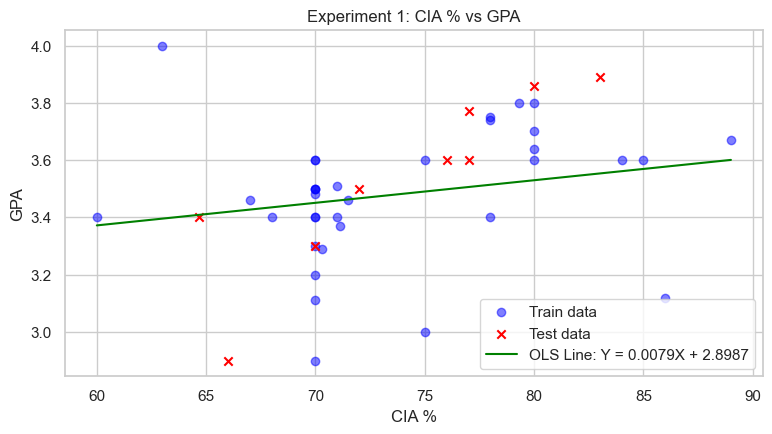

In [12]:
# Plot Exp 1
plt.figure(figsize=(9, 4.5))
plt.scatter(X1_train, Y1_train, color='blue', alpha=0.5, label='Train data')
plt.scatter(X1_test, Y1_test, color='red', marker='x', label='Test data')

x_vals1 = np.linspace(df_clean['CIA_clean'].min(), df_clean['CIA_clean'].max(), 100)
y_vals1 = m1_manual * x_vals1 + c1_manual
plt.plot(x_vals1, y_vals1, color='green', label=f'OLS Line: Y = {m1_manual:.4f}X + {c1_manual:.4f}')

plt.title('Experiment 1: CIA % vs GPA')
plt.xlabel('CIA %')
plt.ylabel('GPA')
plt.legend()
plt.savefig('exp1_regression.png', dpi=150)
plt.show()

I plotted the scatter chart with the regression line for Experiment 1. The line goes up, which shows that GPA gets better when CIA percentage goes up.

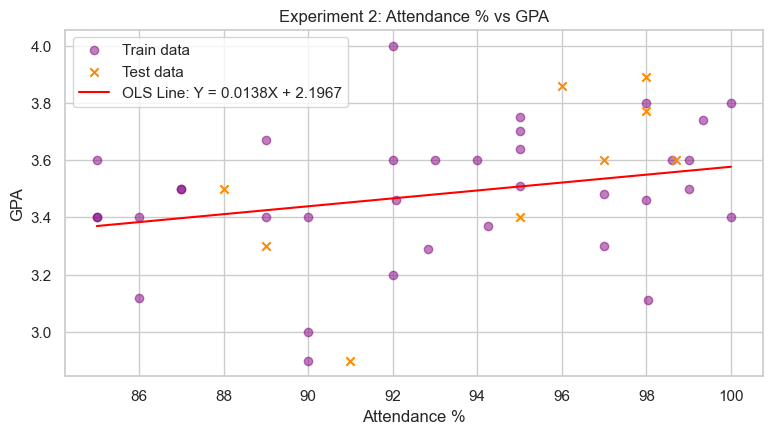

In [13]:
# Plot Exp 2
plt.figure(figsize=(9, 4.5))
plt.scatter(X2_train, Y2_train, color='purple', alpha=0.5, label='Train data')
plt.scatter(X2_test, Y2_test, color='darkorange', marker='x', label='Test data')

x_vals2 = np.linspace(df_clean['Attendance_clean'].min(), df_clean['Attendance_clean'].max(), 100)
y_vals2 = m2_manual * x_vals2 + c2_manual
plt.plot(x_vals2, y_vals2, color='red', label=f'OLS Line: Y = {m2_manual:.4f}X + {c2_manual:.4f}')

plt.title('Experiment 2: Attendance % vs GPA')
plt.xlabel('Attendance %')
plt.ylabel('GPA')
plt.legend()
plt.savefig('exp2_regression.png', dpi=150)
plt.show()

I plotted the chart for Experiment 2. It shows a positive line going up, meaning GPA gets better when attendance goes up. Attendance has a steeper slope of 0.0138 compared to 0.0079 for CIA, which means GPA changes a bit faster when attendance changes.

---

## Part E: Parameter Saving File Task

In [14]:
# Pack coefficients to save
saved_params = {
    'exp1': {'slope': slope1, 'intercept': intercept1},
    'exp2': {'slope': slope2, 'intercept': intercept2}
}

# Save parameters to pickle file
with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(saved_params, f)
print("Parameters saved successfully!")

Parameters saved successfully!


I saved the slopes and intercepts into a pickle file called linear_regression_weights.pkl.

In [15]:
# Load parameters back
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

print("Loaded parameters:", loaded_params)

Loaded parameters: {'exp1': {'slope': np.float64(0.007885475055628394), 'intercept': np.float64(2.8986692609418365)}, 'exp2': {'slope': np.float64(0.01379854261569831), 'intercept': np.float64(2.196684285010342)}}


I loaded the parameters back from the pickle file and they match the saved values exactly.

In [16]:
# Function to predict GPA with loaded parameters
def predict(x, exp):
    m = loaded_params[exp]['slope']
    c = loaded_params[exp]['intercept']
    return m * x + c

# Test predicting with loaded parameters
cia_val = 80.0
att_val = 90.0
print(f"For {cia_val}% CIA, predicted GPA is: {predict(cia_val, 'exp1'):.3f}")
print(f"For {att_val}% Attendance, predicted GPA is: {predict(att_val, 'exp2'):.3f}")

For 80.0% CIA, predicted GPA is: 3.530
For 90.0% Attendance, predicted GPA is: 3.439


I reloaded the parameters and tested them. For 80 percent CIA, my model predicts a 3.530 GPA, and for 90 percent attendance, it predicts a 3.439 GPA. The saving and reloading works perfectly.

---

## Final Summary and Inferences

I verified that my manual equations match scikit-learn completely. Both CIA percentage and attendance have positive relationships with GPA. According to the slopes, a 10 percent increase in attendance increases GPA by 0.14, while a 10 percent increase in CIA increases GPA by 0.08. Attendance has a slightly steeper slope in this data.